# Delphi QC

### GOALS: 

1. Format harp data into a dataframe
2. Produce QC plots
3. Pokeclips generation

## The code below relies on the aeon-api
#### Installations and setup instructions: 
1. Install aeon_mecha by following these instructions: https://aeon.swc.ucl.ac.uk/getting_started/installation.html#target-install-aeon-mecha
2. Create a Jupyter kernel by using ipykernel (Claude does a great job at this).
3. Choose that kernel in the notebook (may need to reopen the notebook).

#### Documentation:
- General information on aeon: https://aeon.swc.ucl.ac.uk/user/index.html
- aeon API (source code): https://github.com/SainsburyWellcomeCentre/aeon_api/tree/main

#### Additional Notes:
- I modified some of the functions in the aeon-api (e.g. triggerclip) because it didn't work properly. 

In [1]:
# import python libraries
import swc.aeon
import swc.aeon.io.reader as reader
import swc.aeon.io.api as aeon_api
import swc.aeon.io.video as aeon_video
import swc.aeon.analysis.movies as video_analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pathlib
import cv2
import datetime

### Load dataset using aeon-api

In [134]:
# Root of path to dataset
root_path = pathlib.Path(r"\\allen\aind\stage\chronic\data\2026-01-06T22-17-14")
# root_path = pathlib.Path(r"\\allen\aind\stage\chronic\data_mouse3\2026-01-07T17-13-53")
# root_path = pathlib.Path(r"C:\Users\brandon.pratt\Desktop\data\2026-01-06T22-49-36")


# Start time for dataset
start_cutoff = datetime.datetime(2025, 1, 1, 0, 0, 0)  # UTC

# Define readers for delphi dataset
readers = {
    "valve_state": reader.Harp("DelphiController_32*", columns=["ValveState"]),
    "poke_times": reader.Harp("DelphiController_61*", columns=["PokeState"]),
    "beam_breaks": reader.Harp("DelphiController_62*", columns=["BeamBreakState"]),
    "vacuum_close_time": reader.Harp(
        "DelphiController_67*", columns=["VacuumCloseTimeUS"]
    ),
    "min_odor_delivery_time": reader.Harp(
        "DelphiController_68*", columns=["MinOdorDeliveryTimeUS"]
    ),
    "max_odor_delivery_time": reader.Harp(
        "DelphiController_69*", columns=["MaxOdorDeliveryTimeUS"]
    ),
    "odor_transition_time": reader.Harp(
        "DelphiController_70*", columns=["OdorTransitionTimeUS"]
    ),
    "vacuum_setup_time": reader.Harp(
        "DelphiController_71*", columns=["VacuumSetupTimeUS"]
    ),
    "final_valve_energized_time": reader.Harp(
        "DelphiController_72*", columns=["FinalValveEnergizedTimeUS"]
    ),
    "min_poke_time": reader.Harp("DelphiController_73*", columns=["MinimumPokeTimeUS"]),
    "cam_triggers": reader.Harp("DelphiController_75*", columns=["PwmRiseEvent"]),
    "frame_rate": reader.Harp("DelphiController_76*", columns=["FrameRate"]),
    "port_video": reader.Video("PortCamera*"),
}

# Load data using the AEON API
valve_state = aeon_api.load(root_path, readers["valve_state"], start=start_cutoff)
poke_times = aeon_api.load(root_path, readers["poke_times"], start=start_cutoff)
beam_breaks = aeon_api.load(root_path, readers["beam_breaks"], start=start_cutoff)
vac_close_time = (
    aeon_api.load(root_path, readers["vacuum_close_time"]) * 1e-6
)  # Convert microseconds to seconds
min_odor_delivery_time = (
    aeon_api.load(root_path, readers["min_odor_delivery_time"]) * 1e-6
)
max_odor_delivery_time = (
    aeon_api.load(root_path, readers["max_odor_delivery_time"]) * 1e-6
)
odor_transition_time = aeon_api.load(root_path, readers["odor_transition_time"]) * 1e-6
vac_setup_time = aeon_api.load(root_path, readers["vacuum_setup_time"]) * 1e-6
final_valve_vac_time = (
    aeon_api.load(root_path, readers["final_valve_energized_time"]) * 1e-6
)
min_poke_time = aeon_api.load(root_path, readers["min_poke_time"]) * 1e-6
trigger_data = aeon_api.load(root_path, readers["cam_triggers"], start=start_cutoff)
frame_rate = aeon_api.load(root_path, readers["frame_rate"], start=start_cutoff)
# portcamera_data = aeon_api.load(root_path, readers["port_video"], start=start_cutoff)

# AEON assumes that videos are .avi, but ours are .mp4 -- fix that here
# portcamera_data["_path"] = portcamera_data["_path"].str.replace(".avi", ".mp4")

In [25]:
np.diff(aeon_api.to_seconds(poke_times.index)).shape

(679,)

In [135]:
def check_state_timings(
    state_timings: list[pd.DataFrame], default_values: list[int]
) -> None:
    for i, j in enumerate(state_timings):
        if j.empty:
            print(f"{j.columns[0]} is empty, assigning default value.")
            j[j.columns[0]] = [default_values[i]]

In [136]:
poke_times

,PokeState
time,
2026-01-06 22:24:17.662591934,1
2026-01-06 22:26:25.302720070,1
2026-01-06 22:29:06.711743832,1
2026-01-06 22:30:00.866975784,1
2026-01-06 22:32:06.198815823,1
...,...
2026-02-06 13:38:56.927231789,1
2026-02-06 13:38:58.139743805,1
2026-02-06 13:39:20.474112034,1


In [29]:
vac_close_time

,VacuumCloseTimeUS
time,


In [137]:
# Check state timings and assign default values if empty
state_timings = [
    vac_close_time,
    min_odor_delivery_time,
    max_odor_delivery_time,
    odor_transition_time,
    vac_setup_time,
    final_valve_vac_time,
    min_poke_time,
]
default_times = [0.02, 0.01, 10, 0.03, 0.02, 0.11, 0.01]  # in seconds
check_state_timings(state_timings, default_times)


VacuumCloseTimeUS is empty, assigning default value.
MinOdorDeliveryTimeUS is empty, assigning default value.
MaxOdorDeliveryTimeUS is empty, assigning default value.
OdorTransitionTimeUS is empty, assigning default value.
VacuumSetupTimeUS is empty, assigning default value.
FinalValveEnergizedTimeUS is empty, assigning default value.
MinimumPokeTimeUS is empty, assigning default value.


### Create DataFrame with the following columns:
1. Port number
2. Current odor
3. Poke boolean
4. Beam break time
5. Beam break duration
6. Expected min poke time
7. Odor delivery onset
8. Odor delivery offset
9. Odor delivery duration
10. Expected min odor delivery time
11. Expected max odor delivery time
12. Odor transition onset
13. Odor transition offset
14. Odor transition duration
15. Expected Odor transition duration
16. Vacuum setup onset
17. Vacuum setup offset
18. Vacuum setup duration
19. Expected vacuum setup duration
20. Final valve + vacuum onset
21. Final valve + vacuum offset
22. Final valve + vacuum duration
23. Expected final valve + vacuum duration
24. Vac close onset
25. Vac close offset
26. Vac close duration
27. Expected vac close duration



In [138]:
"""Initialize DataFrame"""
# column names
cols = [
    "poke_port",
    "poke_registered",
    "poke_number",
    "configured_min_poke_duration",
    "beam_break_onset",
    "beam_break_offset",
    "beam_break_duration",
    "poke_onset",
    "poke_offset",
    "poke_duration",
    "poke_beam_break_delay",
    "odor",
    "odor_delivery_onset",
    "odor_delivery_offset",
    "odor_delivery_duration",
    "configured_min_odor_delivery_duration",
    "configured_max_odor_delivery_duration",
    "odor_transition_onset",
    "odor_transition_offset",
    "odor_transition_duration",
    "configured_odor_transition_duration",
    "vacuum_setup_onset",
    "vacuum_setup_offset",
    "vacuum_setup_duration",
    "configured_vacuum_setup_duration",
    "final_valve_vacuum_onset",
    "final_valve_vacuum_offset",
    "final_valve_vacuum_duration",
    "configured_final_valve_vacuum_duration",
    "next_odor_setup_onset",
    "next_odor_setup_offset",
    "next_odor_setup_duration",
    "configured_next_odor_setup_duration",
    "detected_error",
]

# create empty dataframe
delphi_df = pd.DataFrame(columns=cols)

#### Log errors on a beam break by beam break basis  

In [139]:
# error logging function
def error_logging(df, row_idx, new_error, col="detected_error", sep="_"):
    current = df.loc[row_idx, col]
    if pd.isna(current) or current == "":
        df.loc[row_idx, col] = new_error
    else:
        df.loc[row_idx, col] = f"{current}{sep}{new_error}"


In [140]:
"""Fill DataFrame"""
# beam break, times, and valve state times
break_onsets = aeon_api.to_seconds(
    beam_breaks[beam_breaks["BeamBreakState"] == 1].index
)
break_offsets = aeon_api.to_seconds(
    beam_breaks[beam_breaks["BeamBreakState"] == 0].index
)
valve_state_times = aeon_api.to_seconds(valve_state.index)
poke_detected_times = aeon_api.to_seconds(
    poke_times[poke_times["PokeState"] == 1].index
)

# Configuration delphi parameters
poke_n = 0
min_poke_tol = 0.0025  # 2.5 ms tolerance for poke detection
configured_min_poke_duration = min_poke_time.iloc[0].values[0]
configured_min_odor_delivery_duration = min_odor_delivery_time.iloc[0].values[0]
configured_max_odor_delivery_duration = max_odor_delivery_time.iloc[0].values[0]
configured_odor_transition_duration = odor_transition_time.iloc[0].values[0]
configured_vacuum_setup_duration = vac_setup_time.iloc[0].values[0]
configured_final_valve_vacuum_duration = final_valve_vac_time.iloc[0].values[0]
configured_next_odor_setup_duration = vac_close_time.iloc[0].values[0]

# Find all pokes corresponding to beam breaks
for i, break_onset in enumerate(break_onsets):
    # beam break infomation
    break_offset_idx = np.where((break_offsets.values - break_onset) > 0)[0][0]
    break_offset = break_offsets[break_offset_idx]
    break_duration = break_offset - break_onset

    # Find closest poke time to beam break onset with the assumption that pokes are registered after beam breaks
    try:
        poke_idx = np.where((poke_detected_times.values - break_onset) > 0)[0][0]
        beam_poke_dt = poke_detected_times.values[poke_idx] - break_onset

        # Fill in dataframe with available information
        delphi_df.loc[i, "poke_port"] = 1  # assuming single port
        delphi_df.loc[i, "configured_min_poke_duration"] = configured_min_poke_duration
        delphi_df.loc[i, "configured_min_odor_delivery_duration"] = (
            configured_min_odor_delivery_duration
        )
        delphi_df.loc[i, "configured_max_odor_delivery_duration"] = (
            configured_max_odor_delivery_duration
        )
        delphi_df.loc[i, "configured_odor_transition_duration"] = (
            configured_odor_transition_duration
        )
        delphi_df.loc[i, "configured_vacuum_setup_duration"] = (
            configured_vacuum_setup_duration
        )
        delphi_df.loc[i, "configured_final_valve_vacuum_duration"] = (
            configured_final_valve_vacuum_duration
        )
        delphi_df.loc[i, "configured_next_odor_setup_duration"] = (
            configured_next_odor_setup_duration
        )
        delphi_df.loc[i, "beam_break_onset"] = break_onset
        delphi_df.loc[i, "beam_break_offset"] = break_offset
        delphi_df.loc[i, "beam_break_duration"] = break_duration
        delphi_df.loc[i, "poke_beam_break_delay"] = beam_poke_dt

        # Poke is registed between beam onset and offset
        if (poke_detected_times.values[poke_idx] >= break_onset) and (
            poke_detected_times.values[poke_idx] <= break_offset
        ):
            # print(f"Poke registered for beam break at time {break_onset:.4f}s")
            poke_registered = True
            poke_n += 1

            # Find closest valve state change to when a poke was detected
            valve_idx = np.argmin(
                np.abs(poke_detected_times.values[poke_idx] - valve_state_times.values)
            )

            # Determine odor -- produce an error if there is no index or value doesn't match an odor value slot
            try:
                odor_at_poke = valve_state.iloc[valve_idx - 1].values[0]
            except (IndexError, ValueError):
                delphi_df.loc[i, "detected_error"] = "Odor index not found"
                odor_at_poke = None

            # Check that valve state sequence is correct
            if odor_at_poke < 4:
                print("Odor value is invalid. Must be 4 or greater.")
                error_logging(delphi_df, i, "Invalid odor value")

            if valve_state.iloc[valve_idx].values[0] != odor_at_poke + 1:
                print("Final valve + odor state is missing or out of sequence.")
                error_logging(
                    delphi_df,
                    i,
                    "Final valve + odor state is missing or out of sequence",
                )

            if valve_state.iloc[valve_idx + 1].values[0] != odor_at_poke:
                print("Post final valve odor state is missing or out of sequence.")
                error_logging(
                    delphi_df,
                    i,
                    "Post final valve odor state is missing or out of sequence",
                )

            if valve_state.iloc[valve_idx + 2].values[0] != 2:
                print("Vacuum setup state is missing or out of sequence.")
                error_logging(
                    delphi_df, i, "Vacuum setup state is missing or out of sequence"
                )

            if valve_state.iloc[valve_idx + 3].values[0] != 3:
                print("Vacuum + final valve state is missing or out of sequence.")
                error_logging(
                    delphi_df,
                    i,
                    "Vacuum + final valve state is missing or out of sequence",
                )

            # get all the valve state information
            odor = format(
                odor_at_poke, "016b"
            )  # Convert to 16-bit binary string without the final valve included
            odor_delivery_onset = valve_state_times.values[valve_idx]
            odor_delivery_offset = valve_state_times.values[valve_idx + 1]
            odor_delivery_duration = (
                odor_delivery_offset - odor_delivery_onset
            )  # in seconds
            odor_transition_onset = valve_state_times.values[valve_idx + 1]
            odor_transition_offset = valve_state_times.values[valve_idx + 2]
            odor_transition_duration = (
                odor_transition_offset - odor_transition_onset
            )  # in seconds
            vacuum_setup_onset = valve_state_times.values[valve_idx + 2]
            vacuum_setup_offset = valve_state_times.values[valve_idx + 3]
            vacuum_setup_duration = (
                vacuum_setup_offset - vacuum_setup_onset
            )  # in seconds
            final_valve_vacuum_onset = valve_state_times.values[valve_idx + 3]
            final_valve_vacuum_offset = valve_state_times.values[valve_idx + 4]
            final_valve_vacuum_duration = (
                final_valve_vacuum_offset - final_valve_vacuum_onset
            )  # in seconds
            next_odor_setup_onset = valve_state_times.values[valve_idx + 4]
            next_odor_setup_offset = valve_state_times.values[valve_idx + 5]
            next_odor_setup_duration = (
                next_odor_setup_offset - next_odor_setup_onset
            )  # in seconds

            # Add information to dataframe
            delphi_df.loc[i, "poke_registered"] = poke_registered
            delphi_df.loc[i, "poke_number"] = poke_n
            delphi_df.loc[i, "poke_onset"] = poke_detected_times.values[poke_idx]
            delphi_df.loc[i, "poke_offset"] = break_offset
            delphi_df.loc[i, "poke_duration"] = (
                break_offset - poke_detected_times.values[poke_idx]
            )
            delphi_df.loc[i, "odor"] = odor
            delphi_df.loc[i, "odor_delivery_onset"] = odor_delivery_onset
            delphi_df.loc[i, "odor_delivery_offset"] = odor_delivery_offset
            delphi_df.loc[i, "odor_delivery_duration"] = odor_delivery_duration
            delphi_df.loc[i, "odor_transition_onset"] = odor_transition_onset
            delphi_df.loc[i, "odor_transition_offset"] = odor_transition_offset
            delphi_df.loc[i, "odor_transition_duration"] = odor_transition_duration
            delphi_df.loc[i, "vacuum_setup_onset"] = vacuum_setup_onset
            delphi_df.loc[i, "vacuum_setup_offset"] = vacuum_setup_offset
            delphi_df.loc[i, "vacuum_setup_duration"] = vacuum_setup_duration
            delphi_df.loc[i, "final_valve_vacuum_onset"] = final_valve_vacuum_onset
            delphi_df.loc[i, "final_valve_vacuum_offset"] = final_valve_vacuum_offset
            delphi_df.loc[i, "final_valve_vacuum_duration"] = (
                final_valve_vacuum_duration
            )
            delphi_df.loc[i, "next_odor_setup_onset"] = next_odor_setup_onset
            delphi_df.loc[i, "next_odor_setup_offset"] = next_odor_setup_offset
            delphi_df.loc[i, "next_odor_setup_duration"] = next_odor_setup_duration
        else:
            delphi_df.loc[i, "poke_registered"] = False  # no poke registered
    except IndexError:
        print(f"No poke found for beam break at time {break_onset:.4f}s")
        delphi_df.loc[i, "poke_registered"] = False  # no poke registered

# Check for pokes that were registered but not within the valid beam break window
remaining_pokes = np.setdiff1d(
    poke_detected_times.values, delphi_df["poke_onset"].dropna().values
)
for poke_time in remaining_pokes:
    # find closest beam break to the poke time
    beam_idx = np.where(-(poke_time - break_onsets) >= 0)[0][0]
    beam_onset = break_onsets[beam_idx]

    # Check the dataframe to see if the beam break is contained
    # Spirious poke occured
    if not delphi_df["beam_break_onset"].eq(beam_onset).any():
        print(f"Poke at time {poke_time} has no corresponding beam break event.")
        delphi_df.loc[delphi_df.index[-1] + 1, "poke_registered"] = True
        error_logging(delphi_df, delphi_df.index[-1] + 1, "Poke without beam break")


Vacuum setup state is missing or out of sequence.
Vacuum + final valve state is missing or out of sequence.
Vacuum setup state is missing or out of sequence.
Vacuum + final valve state is missing or out of sequence.
Vacuum setup state is missing or out of sequence.
Vacuum + final valve state is missing or out of sequence.
Vacuum setup state is missing or out of sequence.
Vacuum + final valve state is missing or out of sequence.


In [141]:
delphi_df

,poke_port,poke_registered,poke_number,configured_min_poke_duration,beam_break_onset,beam_break_offset,beam_break_duration,poke_onset,poke_offset,poke_duration,...,configured_vacuum_setup_duration,final_valve_vacuum_onset,final_valve_vacuum_offset,final_valve_vacuum_duration,configured_final_valve_vacuum_duration,next_odor_setup_onset,next_odor_setup_offset,next_odor_setup_duration,configured_next_odor_setup_duration,detected_error
0,1,True,1,0.01,3850583057.652544,3850583057.87088,0.218336,3850583057.662592,3850583057.87088,0.208288,...,0.02,3850583057.901088,3850583057.901312,0.000224,0.11,3850583057.901312,3850583058.018432,0.11712,0.02,NaN
1,1,True,2,0.01,3850583185.292672,3850583185.48496,0.192288,3850583185.30272,3850583185.48496,0.18224,...,0.02,3850583185.515168,3850583185.515392,0.000224,0.11,3850583185.515392,3850583185.622624,0.107232,0.02,NaN
2,1,True,3,0.01,3850583346.701728,3850583346.818784,0.117056,3850583346.711744,3850583346.818784,0.10704,...,0.02,3850583346.848992,3850583346.849184,0.000192,0.11,3850583346.849184,3850583346.958976,0.109792,0.02,NaN
3,1,True,4,0.01,3850583400.856928,3850583400.935456,0.078528,3850583400.866976,3850583400.935456,0.06848,...,0.02,3850583400.965632,3850583400.965856,0.000224,0.11,3850583400.965856,3850583401.077856,0.112,0.02,NaN
4,1,True,5,0.01,3850583526.188768,3850583526.313056,0.124288,3850583526.198816,3850583526.313056,0.11424,...,0.02,3850583526.343296,3850583526.343456,0.00016,0.11,3850583526.343456,3850583526.457696,0.11424,0.02,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4140,1,True,3112,0.01,3853229936.917184,3853229937.293536,0.376352,3853229936.927232,3853229937.293536,0.366304,...,0.02,3853229937.323744,3853229937.323936,0.000192,0.11,3853229937.323936,3853229937.430112,0.106176,0.02,NaN
4141,1,True,3113,0.01,3853229938.129728,3853229938.177248,0.047521,3853229938.139744,3853229938.177248,0.037505,...,0.02,3853229938.207424,3853229938.207648,0.000224,0.11,3853229938.207648,3853229938.325888,0.11824,0.02,NaN
4142,1,True,3114,0.01,3853229960.464064,3853229960.536512,0.072448,3853229960.474112,3853229960.536512,0.0624,...,0.02,3853229960.56672,3853229960.566944,0.000224,0.11,3853229960.566944,3853229960.683168,0.116224,0.02,NaN
4143,1,True,3115,0.01,3853230142.777568,3853230144.069696,1.292128,3853230142.787616,3853230144.069696,1.28208,...,0.02,3853230144.099904,3853230144.100096,0.000192,0.11,3853230144.100096,3853230144.209696,0.1096,0.02,NaN


### Valve QC Plots

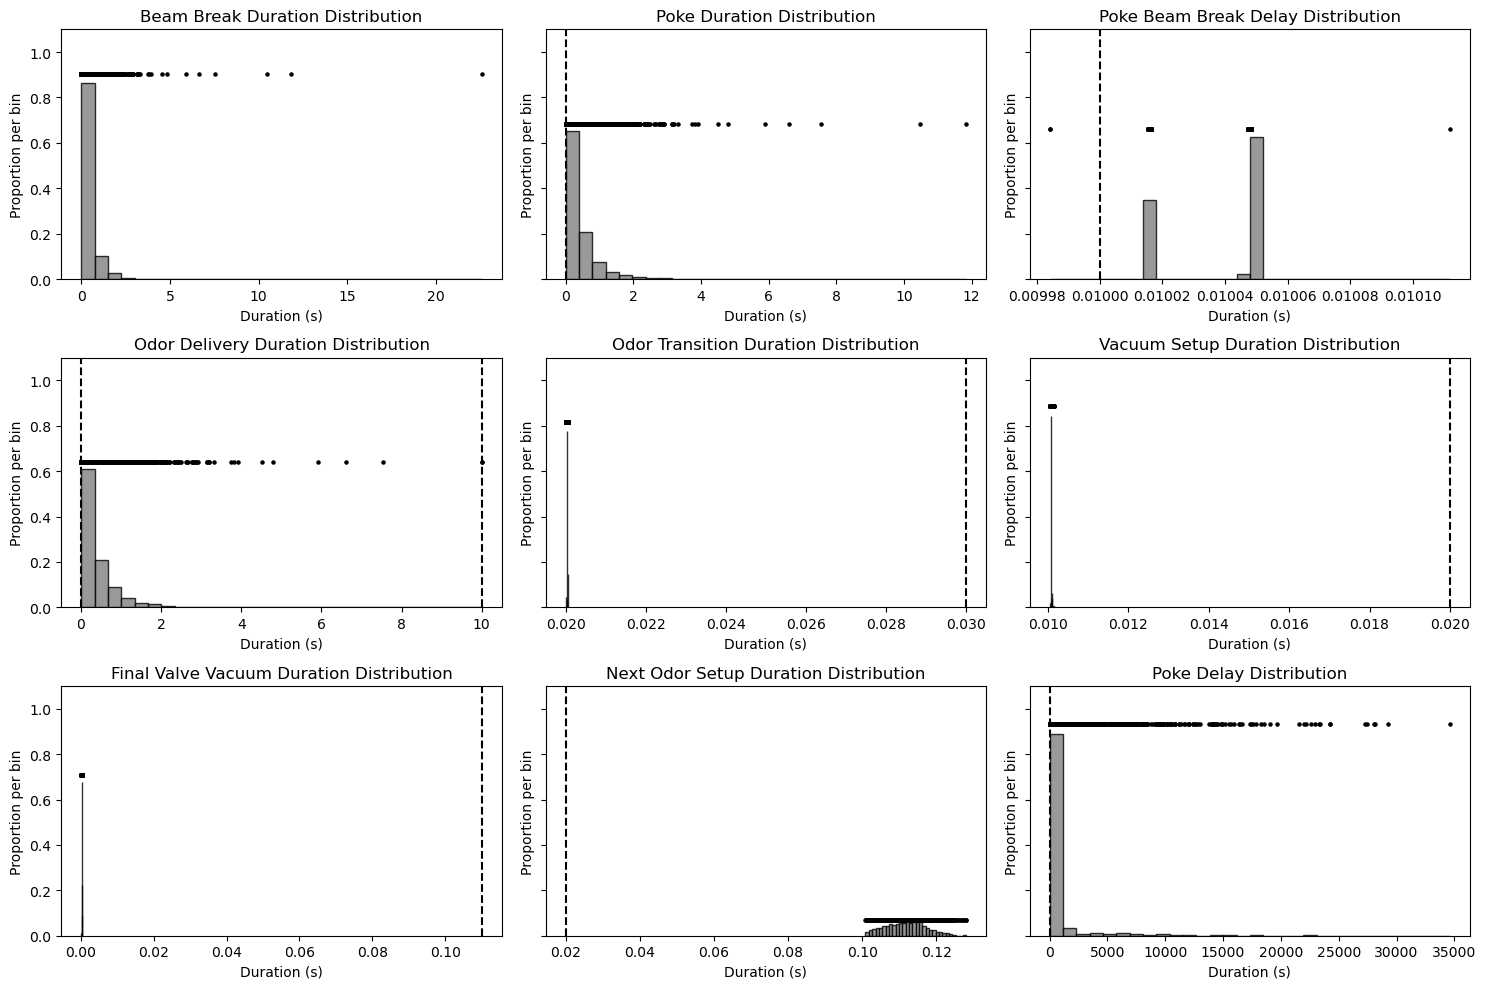

In [142]:
def prob_hist_with_scatter(ax, series, bins=30, title="", xlabel="", vlines=None):
    """
    Plot probability-per-bin histogram (PMF-like) using weights so that sum of heights = 1.
    Also places a thin scatter band slightly above the tallest bar.
    """
    # Clean data once
    data = series.dropna().to_numpy()
    if data.size == 0:
        ax.set_title(title + " (no data)")
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Probability per bin")
        return

    # Build weights for probability per bin
    weights = np.ones_like(data, dtype=float) / data.size

    # Plot histogram with probability per bin
    probs, bin_edges, patches = ax.hist(
        data,
        bins=bins,  # can be an int or explicit edges array
        color="gray",
        alpha=0.8,
        weights=weights,  # <- key: normalizes to sum=1 across bins
        edgecolor="black",
    )

    # Scatter slightly above max probability
    y_top = probs.max() if probs.size else 0.0
    y_scatter = y_top * 1.05 if y_top > 0 else 0.05  # fallback if uniform/flat
    ax.scatter(
        data,
        np.full(data.shape[0], y_scatter),
        color="black",
        s=5,
        zorder=3,
    )

    # Optional vertical reference lines
    if vlines:
        for x, label in vlines:
            ax.axvline(x=x, color="black", linestyle="--", label=label)
        # ax.legend()

    # Cosmeticsx
    ax.ticklabel_format(style="plain", useOffset=False, axis="x")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Proportion per bin")

    # Keep some headroom above scatter
    ax.set_ylim(0, 1.1)


# Plot results
fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharey=True)

# Beam break duration
prob_hist_with_scatter(
    axes[0, 0],
    delphi_df["beam_break_duration"],
    bins=30,
    title="Beam Break Duration Distribution",
    xlabel="Duration (s)",
)

# Poke duration
prob_hist_with_scatter(
    axes[0, 1],
    delphi_df["poke_duration"],
    bins=30,
    title="Poke Duration Distribution",
    xlabel="Duration (s)",
    vlines=[(configured_min_poke_duration, "Configured Min Poke Duration")],
)

# Delay between beam break and poke onset
prob_hist_with_scatter(
    axes[0, 2],
    delphi_df["poke_beam_break_delay"][delphi_df["poke_registered"] == True],
    bins=30,
    title="Poke Beam Break Delay Distribution",
    xlabel="Duration (s)",
    vlines=[(configured_min_poke_duration, "Configured Min Poke Duration")],
)

# Odor delivery duration
prob_hist_with_scatter(
    axes[1, 0],
    delphi_df["odor_delivery_duration"],
    bins=30,
    title="Odor Delivery Duration Distribution",
    xlabel="Duration (s)",
    vlines=[
        (
            configured_min_odor_delivery_duration,
            "Configured Min Odor Delivery Duration",
        ),
        (
            configured_max_odor_delivery_duration,
            "Configured Max Odor Delivery Duration",
        ),
    ],
)

# Odor transition duration
prob_hist_with_scatter(
    axes[1, 1],
    delphi_df["odor_transition_duration"],
    bins=30,
    title="Odor Transition Duration Distribution",
    xlabel="Duration (s)",
    vlines=[
        (configured_odor_transition_duration, "Configured Odor Transition Duration")
    ],
)

# Vacuum setup duration
prob_hist_with_scatter(
    axes[1, 2],
    delphi_df["vacuum_setup_duration"],
    bins=30,
    title="Vacuum Setup Duration Distribution",
    xlabel="Duration (s)",
    vlines=[(configured_vacuum_setup_duration, "Configured Vacuum Setup Duration")],
)

# Final valve vacuum duration
prob_hist_with_scatter(
    axes[2, 0],
    delphi_df["final_valve_vacuum_duration"],
    bins=30,
    title="Final Valve Vacuum Duration Distribution",
    xlabel="Duration (s)",
    vlines=[
        (
            configured_final_valve_vacuum_duration,
            "Configured Final Valve Vacuum Duration",
        )
    ],
)

# Next odor setup duration
prob_hist_with_scatter(
    axes[2, 1],
    delphi_df["next_odor_setup_duration"],
    bins=30,
    title="Next Odor Setup Duration Distribution",
    xlabel="Duration (s)",
    vlines=[
        (configured_next_odor_setup_duration, "Configured Next Odor Setup Duration")
    ],
)

# Poke delay distribution
poke_delay = delphi_df["poke_onset"].dropna().iloc[1::].reset_index(
    drop=True
) - delphi_df["next_odor_setup_onset"].dropna().iloc[0:-1].reset_index(drop=True)
# Use the helper with a numpy array directly
prob_hist_with_scatter(
    axes[2, 2],
    poke_delay,
    bins=30,
    title="Poke Delay Distribution",
    xlabel="Duration (s)",
    vlines=[
        (configured_next_odor_setup_duration, "Configured Next Odor Setup Duration")
    ],
)

plt.tight_layout()


### Poke interval debugging

In [112]:
break_onsets

Index([ 3850662584.044544, 3850678713.6378565,  3850678714.701568,
        3850678720.411872,  3850692683.226016,  3850692764.881952,
          3850693139.5672,  3850693642.279744,  3850694697.419584,
        3850694709.169472,
       ...
          3851971294.0152,  3851971294.868736,  3851971330.689312,
         3851971331.52832,  3851971336.519616,  3851971360.669216,
        3851971361.199776,  3851978434.842816,  3851978916.616672,
        3851978917.853824],
      dtype='float64', name='time', length=45151)

In [129]:
np.where(break_onsets - poke_detected_times[10] < 0)[-1]

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10], dtype=int64)

In [130]:
match_onset = []
for i in range(len(poke_detected_times)):
    idx = np.where(break_onsets - poke_detected_times[i] < 0)[0][-1]
    match_onset.append(break_onsets[idx])
match_onset = np.array(match_onset)

In [131]:
match_onset

array([3.85066258e+09, 3.85067871e+09, 3.85067871e+09, ...,
       3.85197843e+09, 3.85197892e+09, 3.85197892e+09])

In [133]:
np.min(np.diff(match_onset))

0.016672134399414062

In [74]:
np.max(
    delphi_df["poke_onset"][delphi_df["poke_registered"] == True].dropna()
    - delphi_df["beam_break_onset"][delphi_df["poke_registered"] == True].dropna()
)

0.16684770584106445

In [91]:
np.max(
    delphi_df["poke_onset"][delphi_df["poke_registered"] == True].dropna()
    - delphi_df["beam_break_onset"][delphi_df["poke_registered"] == True].dropna()
)

0.16684770584106445

In [92]:
np.argmax(
    delphi_df["poke_onset"][delphi_df["poke_registered"] == True].dropna()
    - delphi_df["beam_break_onset"][delphi_df["poke_registered"] == True].dropna()
)

10931

In [99]:
3851221557.894592 - 3851221557.500128

0.39446401596069336

In [98]:
delphi_df[["beam_break_onset", "poke_onset", "beam_break_offset"]][
    delphi_df["poke_registered"] == True
].dropna().iloc[10930]

beam_break_onset     3851221557.473696
poke_onset           3851221557.500128
beam_break_offset    3851221557.705664
Name: 14700, dtype: object

In [87]:
np.where(
    (
        np.diff(
            delphi_df["beam_break_onset"][delphi_df["poke_registered"] == True].dropna()
        )
        < 0.170
    )
)[0].shape[0]

2411

In [90]:
# print various values for debugging
print(
    f"{np.min(np.diff(delphi_df['poke_onset'][delphi_df['poke_registered'] == True].dropna()))}s minimum inter-poke interval"
)
print(
    f"{np.min(delphi_df['poke_duration'][delphi_df['poke_registered'] == True].dropna())}s minimum poke duration"
)
print(
    f"{np.min(delphi_df['beam_break_duration'][delphi_df['poke_registered'] == True].dropna())}s minimum beam break duration"
)
print(
    f"{np.min(np.diff(delphi_df['beam_break_onset'][delphi_df['poke_registered'] == True].dropna()))}s minimum beam break onset interval"
)
print(
    f"Number of short inter-beam break onset intervals detected: {np.where((np.diff(delphi_df['beam_break_onset'][delphi_df['poke_registered'] == True].dropna()) < 0.170))[0].shape[0]}"
)
print(
    f"{min(delphi_df['poke_onset'][delphi_df['poke_registered'] == True].dropna() - delphi_df['beam_break_onset'][delphi_df['poke_registered'] == True].dropna())}s minimum poke delay"
)
print(
    f"{max(delphi_df['poke_onset'][delphi_df['poke_registered'] == True].dropna() - delphi_df['beam_break_onset'][delphi_df['poke_registered'] == True].dropna())}s maximum poke delay"
)
print(f"Number of beam break onsets: {break_onsets.shape}")
print(f"Number of beam break onsets: {break_offsets.shape}")
print(f"Number of pokes registered in dataframe: {delphi_df['poke_registered'].sum()}")
print(f"Number of pokes detected: {poke_times.shape[0]}")

0.17017602920532227s minimum inter-poke interval
0.00019216537475585938s minimum poke duration
0.01017618179321289s minimum beam break duration
0.016672134399414062s minimum beam break onset interval
Number of short inter-beam break onset intervals detected: 2411
0.00985574722290039s minimum poke delay
0.16684770584106445s maximum poke delay
Number of beam break onsets: (45151,)
Number of beam break onsets: (45151,)
Number of pokes registered in dataframe: 30467
Number of pokes detected: 30467


In [32]:
min(np.diff(delphi_df["beam_break_onset"][delphi_df["poke_registered"] == True]))

0.016672134399414062

In [22]:
inter_poke = np.diff(
    delphi_df["beam_break_onset"][delphi_df["poke_registered"] == True]
    .dropna()
    .to_numpy()
)

poke_dur = (
    delphi_df["beam_break_offset"][delphi_df["poke_registered"] == True]
    .dropna()
    .to_numpy()
    - delphi_df["beam_break_onset"][delphi_df["poke_registered"] == True]
    .dropna()
    .to_numpy()
)

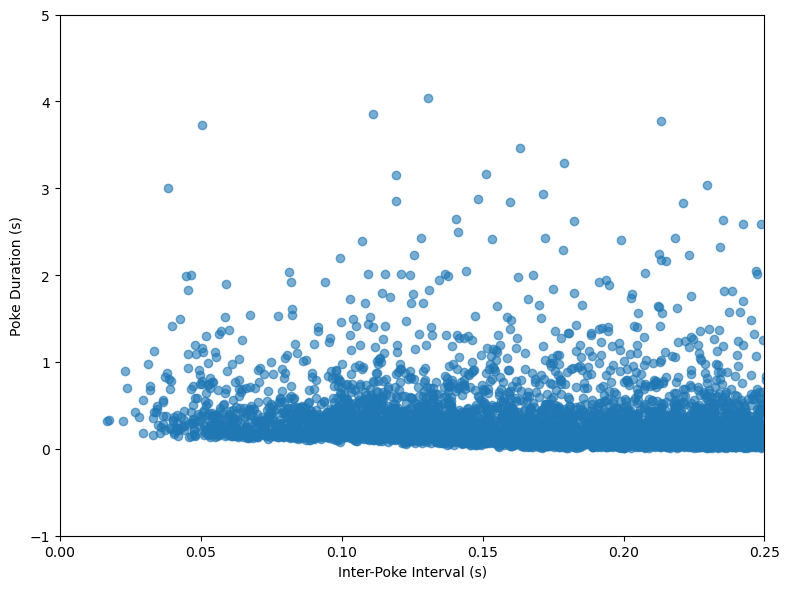

In [27]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(inter_poke, poke_dur[1::], alpha=0.6)
ax.set_ylim(-1, 5)
ax.set_xlim(0, 0.25)
ax.set_xlabel("Inter-Poke Interval (s)")
ax.set_ylabel("Poke Duration (s)")
plt.tight_layout()
plt.show()

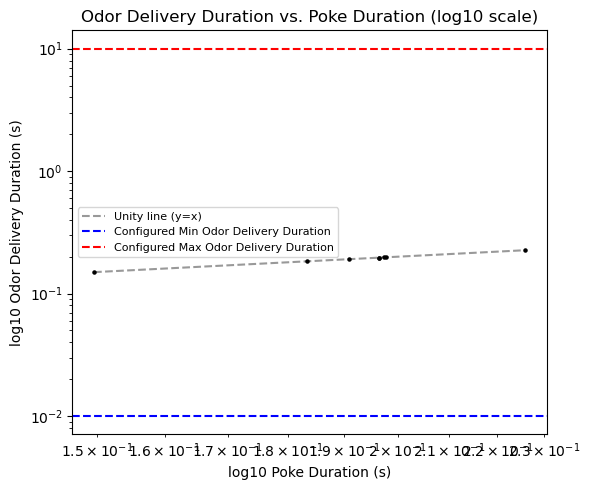

In [316]:
# odor delivery duration vs. poke duration (log10)
fig = plt.figure(figsize=(6, 5))
x = delphi_df["poke_duration"].dropna().to_numpy()
y = delphi_df["odor_delivery_duration"].dropna().to_numpy()

# unity line
min_val = min(np.min(x), np.min(y))
max_val = max(np.max(x), np.max(y))
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="gray",
    linestyle="--",
    label="Unity line (y=x)",
    alpha=0.8,
    zorder=0,
)

# plot data
plt.scatter(x, y, color="k", s=5, zorder=1)
plt.axhline(
    y=configured_min_odor_delivery_duration,
    color="b",
    linestyle="--",
    label="Configured Min Odor Delivery Duration",
)
plt.axhline(
    y=configured_max_odor_delivery_duration,
    color="r",
    linestyle="--",
    label="Configured Max Odor Delivery Duration",
)

# Apply log scale to x & y axes
plt.xscale("log")
plt.yscale("log")

# axes labels and title
plt.xlabel("log10 Poke Duration (s)")
plt.ylabel("log10 Odor Delivery Duration (s)")
plt.title("Odor Delivery Duration vs. Poke Duration (log10 scale)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


### Poke rate computed as an exponential decay

In [143]:
# odor change events
odor_events = []
prev_val = delphi_df["odor"].dropna().values[0]
for i in range(len(delphi_df["odor"].dropna()) - 1):
    if delphi_df["odor"].dropna().values[i + 1] != prev_val:
        odor_events.append(
            (
                delphi_df["poke_onset"].dropna().values[i + 1],
                prev_val,
                delphi_df["odor"].dropna().values[i + 1],
            )
        )
        prev_val = delphi_df["odor"].dropna().values[i + 1]

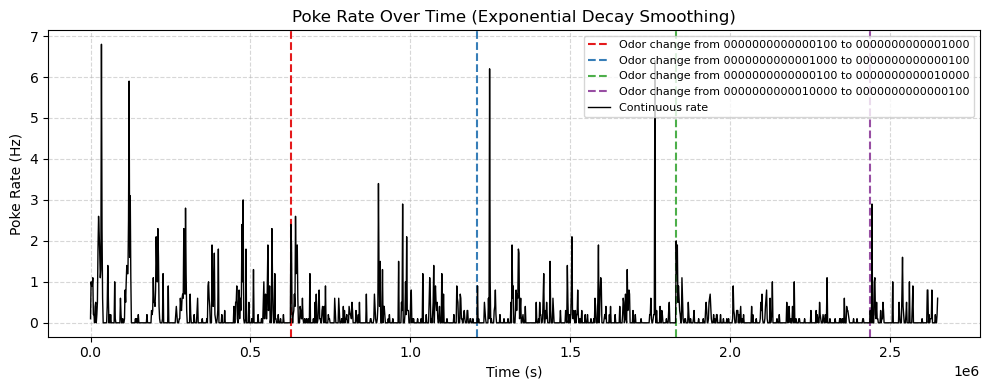

In [144]:
# parameters for plots
tau = 10  # time constant of decay (seconds)
dt = 1800  # sample every n seconds (30 minutes)
poke_events = delphi_df["poke_onset"].dropna().to_numpy() - np.min(
    delphi_df["poke_onset"].dropna().to_numpy()
)

# color map for plotting odor changes dynamically
cmap = plt.get_cmap("Set1")


# poke rate across time
def poke_rate_exponential_decay(t_events, tau=0.5, dt=0.01):
    if t_events.size == 0:
        return np.array([]), np.array([])
    t0, t1 = t_events[0], t_events[-1]
    t_grid = np.arange(t0, t1 + dt, dt)
    s = 0.0
    r_grid = np.zeros_like(t_grid, dtype=float)
    e_idx = 0
    for i, tg in enumerate(t_grid):
        if i > 0:
            s *= np.exp(-dt / tau)  # decay every step
        while e_idx < t_events.size and t_events[e_idx] <= tg:
            s += 1.0  # event impulse
            e_idx += 1
        r_grid[i] = s / tau
    return t_grid, r_grid


# Compute poke rate across time
t_sample, r_poke = poke_rate_exponential_decay(poke_events, tau=tau, dt=dt)

plt.figure(figsize=(10, 4))
for i, (event_time, old_odor, new_odor) in enumerate(odor_events):
    plt.axvline(
        x=event_time - np.min(delphi_df["poke_onset"].dropna().to_numpy()),
        color=cmap(i),
        linestyle="--",
        label=f"Odor change from {old_odor} to {new_odor}",
    )
plt.plot(t_sample, r_poke, color="black", lw=1, label="Continuous rate")
plt.xlabel("Time (s)")
plt.ylabel("Poke Rate (Hz)")
plt.title("Poke Rate Over Time (Exponential Decay Smoothing)")
plt.grid(True, ls="--", alpha=0.5)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


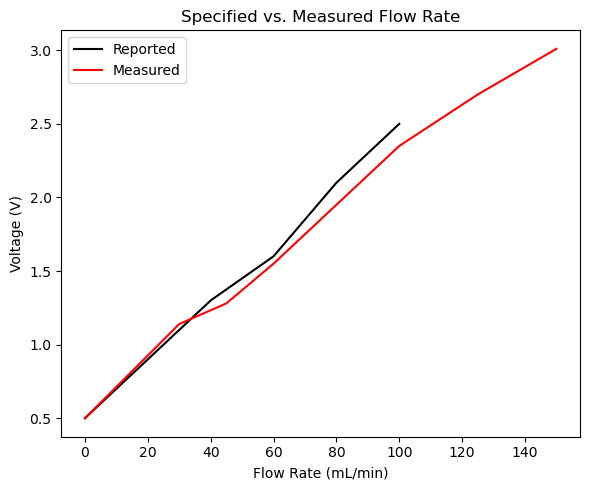

In [147]:
# Flow meter calibration plot
spec_v = np.array([0.5, 0.9, 1.3, 1.6, 2.1, 2.5])
spec_flow = np.array([0, 20, 40, 60, 80, 100])
measured_v = np.array([0.4995, 1.14, 1.28, 1.55, 1.85, 2.35, 2.7, 3.01])
measured_flow = np.array([0, 30, 45, 60, 75, 100, 125, 150])

fig = plt.figure(1, figsize=(6, 5))
plt.plot(spec_flow, spec_v, color="black", label="Reported")
plt.plot(measured_flow, measured_v, color="red", label="Measured")
plt.ylabel("Voltage (V)")
plt.xlabel("Flow Rate (mL/min)")
plt.title("Specified vs. Measured Flow Rate")
plt.legend()
plt.tight_layout()
plt.show()

### Poke rate around odor change event

TypeError: 'Axes' object is not subscriptable

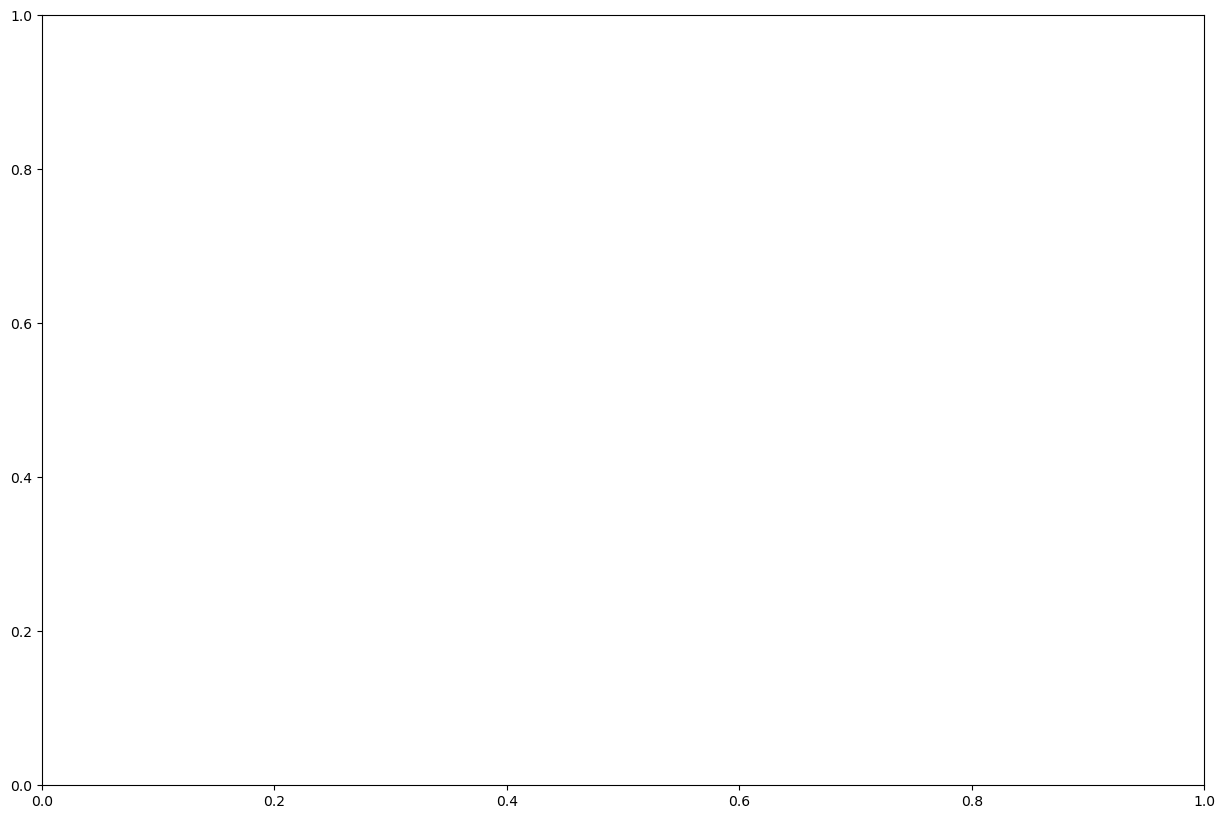

In [235]:
# poke events in a window around the odor changes
tau = 10  # time constant of decay (seconds)
dt = 1800  # sample every n seconds
pre_change_window = 3600 * 24  # seconds = 1 hour
post_change_window = 3600 * 24  # seconds = 1 hour
fig, axes = plt.subplots(1, len(odor_events), figsize=(15, 10), sharey=True)

for i, (event_time, old_odor, new_odor) in enumerate(odor_events):
    # Define time window around odor change
    window_start = event_time - pre_change_window
    window_end = event_time + post_change_window

    # Extract pokes within this window
    pokes_in_window = (
        delphi_df["poke_onset"][
            (delphi_df["poke_onset"] >= window_start)
            & (delphi_df["poke_onset"] <= window_end)
        ]
        .dropna()
        .to_numpy()
    )
    # pokes_in_window = pokes_in_window - np.min(pokes_in_window)

    # plot the poke rate during the analysis window
    t_sample, r_poke = poke_rate_exponential_decay(pokes_in_window, tau=tau, dt=dt)
    axes[i].plot(t_sample, r_poke, color="black", lw=2, label="Continuous rate")
    axes[i].axvline(
        x=event_time, color="red", linestyle="--", label="Odor Change Event"
    )
    axes[i].set_ylabel("Poke Rate (Hz)")
    axes[i].set_xlabel("Time (s)")
    axes[i].set_ylabel("Poke Rate (Hz)")
    axes[i].set_title(f"Odor change from {old_odor} to {new_odor}")
    axes[i].grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


### Cumulative poke counts per day aligned at the time of the odor change

In [294]:
# Choose odor event to plot cumulative pokes relative to
# Specifiy if the odor switch time is manual or automatic (first poke after odor switch)
manual_time = False
if manual_time:
    # Manual entry of odor switch in UTC time
    switch_t = datetime.datetime(2026, 1, 13, 21, 26)  # 801055
    # switch_t = datetime.datetime(2026, 1, 13, 21, 28)  # 835602
    alignment_ts = aeon_api.to_seconds(switch_t)
else:
    odor_event_idx = 0
    alignment_ts = odor_events[odor_event_idx][0]  # time of odor change event


first_poke_t = delphi_df["poke_onset"].dropna().to_numpy()[0]
recent_poke_t = delphi_df["poke_onset"].dropna().to_numpy()[-1]

# Number of days before and after alignment event to plot
day_s = 3600 * 24  # seconds in a day
days_before = int(np.floor((alignment_ts - first_poke_t) / day_s))
days_after = int(np.floor((recent_poke_t - alignment_ts) / day_s))

# Store cumulative pokes and times relative to alignment event
cum_pokes = []
cum_times = []
day_id = []

# Compute the cumulative sum of pokes each day
for day in range(-int(days_before) - 1, int(days_after) + 1):
    # print(day)
    day_start = alignment_ts + (day * day_s)
    day_end = alignment_ts + ((day + 1) * day_s)

    # Extract pokes within this day
    pokes_in_day = delphi_df["poke_onset"][
        (delphi_df["poke_onset"] >= day_start) & (delphi_df["poke_onset"] < day_end)
    ].dropna()

    # Compute cumulative pokes and times relative to alignment event
    cum_poke_counts = np.arange(1, len(pokes_in_day) + 1)
    cum_poke_times = pokes_in_day.to_numpy() - day_start

    cum_pokes.append(cum_poke_counts)
    cum_times.append(cum_poke_times)
    day_id.extend([day])


In [295]:
fig_path = pathlib.Path.cwd().parent.parent.parent.joinpath("figures")

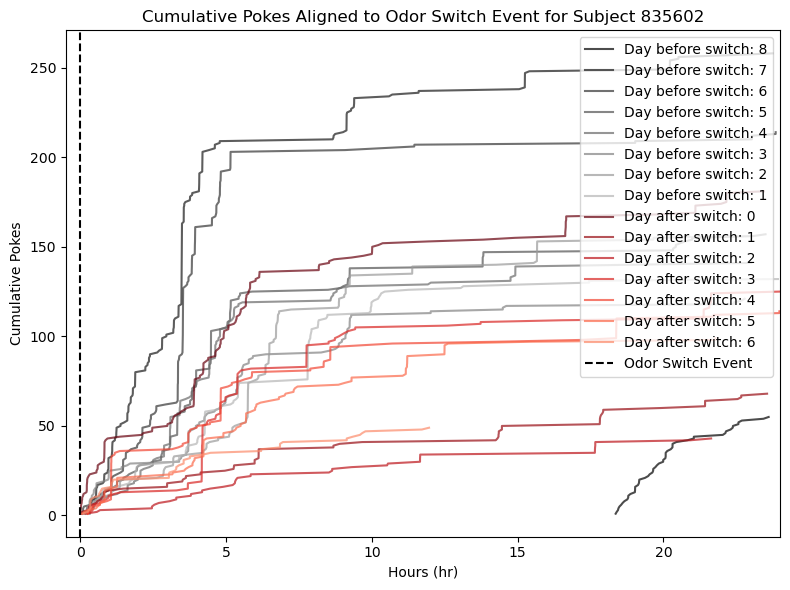

In [296]:
# Plot the culmulative pokes for each day aligned to the time of odor switch
# Cmap for baseline period
subject_id = "835602"  # "801055"  #
cmap_before = plt.get_cmap("Greys")
cmap_before = cmap_before(np.linspace(0.4, 1, days_before + 1))

# Cmap for odor/change period
cmap_after = plt.get_cmap("Reds_r")
cmap_after = cmap_after(np.linspace(0, 0.6, days_after + 1))

fig = plt.figure(figsize=(8, 6))
for i in range(len(cum_pokes)):
    if day_id[i] < 0:
        plt.plot(
            cum_times[i] / 3600,
            cum_pokes[i],
            color=cmap_before[-day_id[i] - 1],
            label=f"Day before switch: {-day_id[i]}",
            alpha=0.7,
        )
    else:
        plt.plot(
            cum_times[i] / 3600,
            cum_pokes[i],
            color=cmap_after[day_id[i]],
            label=f"Day after switch: {day_id[i]}",
            alpha=0.7,
        )
plt.xlabel("Hours (hr)")
plt.ylabel("Cumulative Pokes")
plt.title(f"Cumulative Pokes Aligned to Odor Switch Event for Subject {subject_id}")
plt.xlim([-0.5, 24])
plt.axvline(x=0, color="black", linestyle="--", label="Odor Switch Event")
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Save figure
results_dir = fig_path.joinpath(f"cumulative_pokes_subject_{subject_id}.png")
fig.savefig(
    results_dir,
    dpi=300,
    bbox_inches="tight",
)

In [221]:
fig_path.joinpath(f"cumulative_pokes_subject_{subject_id}.png")

WindowsPath('c:/Users/brandon.pratt/Desktop/figures/cumulative_pokes_subject_801055.png')

### Camera frame rate QC

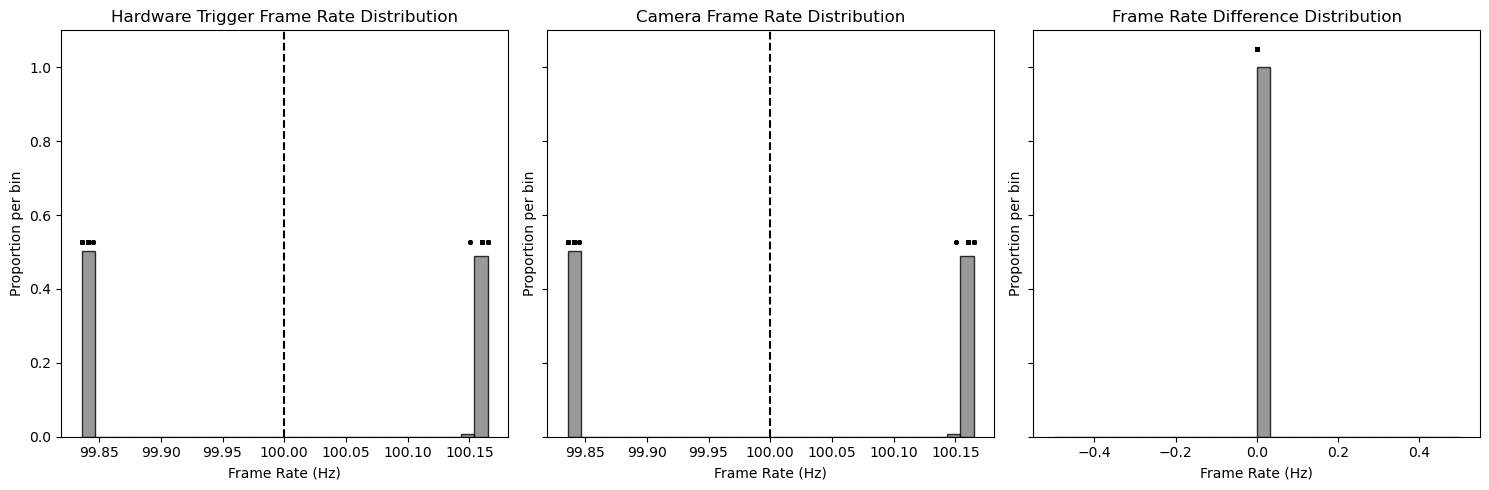

In [317]:
# frame rate distribution
def raw_prob_hist_with_scatter(ax, data, bins=30, title="", xlabel="", vlines=None):
    """
    Plot probability-per-bin histogram (PMF-like) using weights so that sum of heights = 1.
    Also places a thin scatter band slightly above the tallest bar.
    """
    # Clean data once
    if data.size == 0:
        ax.set_title(title + " (no data)")
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Probability per bin")
        return

    # Build weights for probability per bin
    weights = np.ones_like(data, dtype=float) / data.size

    # Plot histogram with probability per bin
    probs, bin_edges, patches = ax.hist(
        data,
        bins=bins,  # can be an int or explicit edges array
        color="gray",
        alpha=0.8,
        weights=weights,  # <- key: normalizes to sum=1 across bins
        edgecolor="black",
    )

    # Scatter slightly above max probability
    y_top = probs.max() if probs.size else 0.0
    y_scatter = y_top * 1.05 if y_top > 0 else 0.05  # fallback if uniform/flat
    ax.scatter(
        data,
        np.full(data.shape[0], y_scatter),
        color="black",
        s=5,
        zorder=3,
    )

    # Optional vertical reference lines
    if vlines:
        for x, label in vlines:
            ax.axvline(x=x, color="black", linestyle="--", label=label)
        # ax.legend()

    # Cosmetics
    ax.ticklabel_format(style="plain", useOffset=False, axis="x")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Proportion per bin")

    # Keep some headroom above scatter
    ax.set_ylim(0, 1.1)


# Plot hardware triggers and camera timestamps
configured_frame_rate = frame_rate["FrameRate"].values[0]
camera_timestamps = aeon_api.to_seconds(portcamera_data.index)
camera_fps = 1 / np.diff(camera_timestamps)


# hardware cameras just when frames were captured
hardware_trigger_timestamps = aeon_api.to_seconds(trigger_data.index)
hardware_trigger_at_camera_frames = np.isin(
    hardware_trigger_timestamps, camera_timestamps
)
hardware_trigger_fps = 1 / np.diff(
    hardware_trigger_timestamps[hardware_trigger_at_camera_frames]
)

# difference in frame rate between hardware triggers and camera timestamps
fps_dt = np.abs(hardware_trigger_fps - camera_fps)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# Hardware trigger fps
raw_prob_hist_with_scatter(
    axes[0],
    hardware_trigger_fps,
    bins=30,
    title="Hardware Trigger Frame Rate Distribution",
    xlabel="Frame Rate (Hz)",
    vlines=[(configured_frame_rate, "Configured Frame Rate")],
)

# Camera fps
raw_prob_hist_with_scatter(
    axes[1],
    camera_fps,
    bins=30,
    title="Camera Frame Rate Distribution",
    xlabel="Frame Rate (Hz)",
    vlines=[(configured_frame_rate, "Configured Frame Rate")],
)

# Difference in fps
raw_prob_hist_with_scatter(
    axes[2],
    fps_dt,
    bins=30,
    title="Frame Rate Difference Distribution",
    xlabel="Frame Rate (Hz)",
)

plt.tight_layout()
plt.show()

### Poke QC -- generate video clips where pokes should be centered in the video 

In [357]:
# Relaxed version of video clipping based on events (i.e. poke times) -- based on the aeon function
def relaxedtriggerclip(data, events, before=None, after=None):
    """Split video data around the specified sequence of event timestamps.

    :param DataFrame data: A pandas DataFrame where each row specifies
      video acquisition path and frame number.
    :param iterable events: A sequence of timestamps to extract.
    :param Timedelta before: The left offset from each timestamp used to clip the data.
    :param Timedelta after: The right offset from each timestamp used to clip the data.
    :return: A pandas DataFrame containing the frames, clip and sequence numbers for each event timestamp.
    """
    if before is None:
        before = pd.Timedelta(0)
    elif before is not pd.Timedelta:
        before = pd.Timedelta(before)

    if after is None:
        after = pd.Timedelta(0)
    elif after is not pd.Timedelta:
        after = pd.Timedelta(after)

    if events is not pd.Index:
        events = events.index

    clips = []
    for i, index in enumerate(events):
        clip = data[
            (data.index >= (index - before)) & (data.index <= (index + after))
        ].copy()
        clip["frame_sequence"] = list(range(len(clip)))
        clip["clip_sequence"] = i
        clips.append(clip)
    return pd.concat(clips)

In [358]:
# function for choosing the format of export videos
"""NOTE: CHANGE THE FAME RATE TO MATCH RECORDED FRAME RATE"""


def video_export_format(
    clips: pd.DataFrame,
    event_ids: np.ndarray,
    export_mode: str,
    results_dir: pathlib.Path,
    fourcc=None,
    fps: int = 100,
) -> None:
    if export_mode == "seperate":
        for i in event_ids:
            curr_video = clips.loc[clips["clip_sequence"] == i]
            poke_timestamp = curr_video.index[int(curr_video.shape[0] / 2)].strftime(
                "%Y%m%d_%H%M%S_%f"
            )  # valid date string
            vid_frames = aeon_video.frames(curr_video)
            aeon_video.export(
                vid_frames,
                file=results_dir.joinpath(f"poke_{i}_{poke_timestamp}.mp4"),
                fps=100,
                fourcc=fourcc,
            )
    elif export_mode == "combined":
        vid_frames = aeon_video.frames(clips)
        aeon_video.export(
            vid_frames,
            file=results_dir.joinpath("combined_video.mp4"),
            fps=fps,
            fourcc=fourcc,
        )

    else:
        raise ValueError("export_mode must be either 'seperate' or 'combined'")


In [361]:
# Analyze video around poke times
window_size = 10  # seconds
half_window = np.timedelta64(int(window_size / 2), "s")

# Use a relaxed version of the clipping function to capture all frames around poke times
portcamera_pokeclips = relaxedtriggerclip(
    portcamera_data, poke_times, before=half_window, after=half_window
)

In [362]:
# Export a video for each poke
results_dir = pathlib.Path().cwd().joinpath("poke-videos")  # saving directory
results_dir.mkdir(parents=True, exist_ok=True)
poke_ids = portcamera_pokeclips["clip_sequence"].unique()

"""CHECK CODEC COMPATIBILITY
    Options for fourcc:
    1. h264: cv2.VideoWriter_fourcc("h", "2", "6", "4")
    2. mp4v: cv2.VideoWriter_fourcc("m", "p", "4", "v")
    3. XVID: cv2.VideoWriter_fourcc("X", "V", "I", "D")
    4. avc1: cv2.VideoWriter_fourcc("a", "v", "c", "1") 
    5. MJPG: cv2.VideoWriter_fourcc("M", "J", "P", "G")
"""
fourcc = cv2.VideoWriter_fourcc("h", "2", "6", "4")
event_sampled_ids = np.arange(0, poke_times.shape[0], 10)  # e.g. every 10th poke

# Export videos
video_export_format(
    portcamera_pokeclips,
    event_sampled_ids,
    "seperate",
    results_dir,
    fourcc=fourcc,
)